In [6]:
import numpy as np

np.random.seed(0)

N = 300
X0 = np.random.randn(N, 2) + [-2, 0]
X1 = np.random.randn(N, 2) + [ 2, 0]

X = np.vstack([X0, X1])
y = np.array([0]*N + [1]*N)
Y = np.eye(2)[y]

In [7]:
def relu(Z):
    return np.maximum(0.01, Z)

def relu_backward(dA, Z):
    dZ = dA.copy()
    dZ[Z <= 0] = 0
    return dZ

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def cross_entropy(y_hat, y):
    return -np.mean(np.sum(y * np.log(y_hat + 1e-9), axis=1))

In [8]:
D = 2
H1, H2, H3 = 32, 32, 16
C = 2

W1 = np.random.randn(D, H1) * 0.1
b1 = np.ones((1, H1)) * 0.1

W2 = np.random.randn(H1, H2) * 0.1
b2 = np.ones((1, H2)) * 0.1

W3 = np.random.randn(H2, H3) * 0.1
b3 = np.ones((1, H3)) * 0.1

W4 = np.random.randn(H3, C) * 0.1
b4 = np.zeros((1, C))

In [9]:
beta1, beta2 = 0.9, 0.999
eps = 1e-8

mW = [np.zeros_like(W1), np.zeros_like(W2), np.zeros_like(W3), np.zeros_like(W4)]
vW = [np.zeros_like(W1), np.zeros_like(W2), np.zeros_like(W3), np.zeros_like(W4)]
mb = [np.zeros_like(b1), np.zeros_like(b2), np.zeros_like(b3), np.zeros_like(b4)]
vb = [np.zeros_like(b1), np.zeros_like(b2), np.zeros_like(b3), np.zeros_like(b4)]

In [10]:
lr = 0.03
t = 0
use_adam = True   # 🔁 switch between SGD / Adam

def train_step(X, Y):
    global W1,W2,W3,W4,b1,b2,b3,b4,t
    global mW,vW,mb,vb

    # ---- Forward ----
    Z1 = X @ W1 + b1; A1 = relu(Z1)
    Z2 = A1 @ W2 + b2; A2 = relu(Z2)
    Z3 = A2 @ W3 + b3; A3 = relu(Z3)
    Z4 = A3 @ W4 + b4
    Y_hat = softmax(Z4)

    loss = cross_entropy(Y_hat, Y)

    # ---- Backward ----
    dZ4 = Y_hat - Y
    dW4 = A3.T @ dZ4 / len(X)
    db4 = np.mean(dZ4, axis=0, keepdims=True)

    dZ3 = relu_backward(dZ4 @ W4.T, Z3)
    dW3 = A2.T @ dZ3 / len(X)
    db3 = np.mean(dZ3, axis=0, keepdims=True)

    dZ2 = relu_backward(dZ3 @ W3.T, Z2)
    dW2 = A1.T @ dZ2 / len(X)
    db2 = np.mean(dZ2, axis=0, keepdims=True)

    dZ1 = relu_backward(dZ2 @ W2.T, Z1)
    dW1 = X.T @ dZ1 / len(X)
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    gradsW = [dW1,dW2,dW3,dW4]
    gradsb = [db1,db2,db3,db4]

    # ---- Optimizer ----
    if use_adam:
        t += 1
        for i,(W,b) in enumerate(zip([W1,W2,W3,W4],[b1,b2,b3,b4])):
            mW[i] = beta1*mW[i] + (1-beta1)*gradsW[i]
            vW[i] = beta2*vW[i] + (1-beta2)*(gradsW[i]**2)
            mb[i] = beta1*mb[i] + (1-beta1)*gradsb[i]
            vb[i] = beta2*vb[i] + (1-beta2)*(gradsb[i]**2)

            mWc = mW[i] / (1 - beta1**t)
            vWc = vW[i] / (1 - beta2**t)
            mbc = mb[i] / (1 - beta1**t)
            vbc = vb[i] / (1 - beta2**t)

            W -= lr * mWc / (np.sqrt(vWc) + eps)
            b -= lr * mbc / (np.sqrt(vbc) + eps)
    else:
        W1 -= lr*dW1; b1 -= lr*db1
        W2 -= lr*dW2; b2 -= lr*db2
        W3 -= lr*dW3; b3 -= lr*db3
        W4 -= lr*dW4; b4 -= lr*db4

    return loss

/opt/anaconda3/envs/mlops-env/lib/python3.10/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


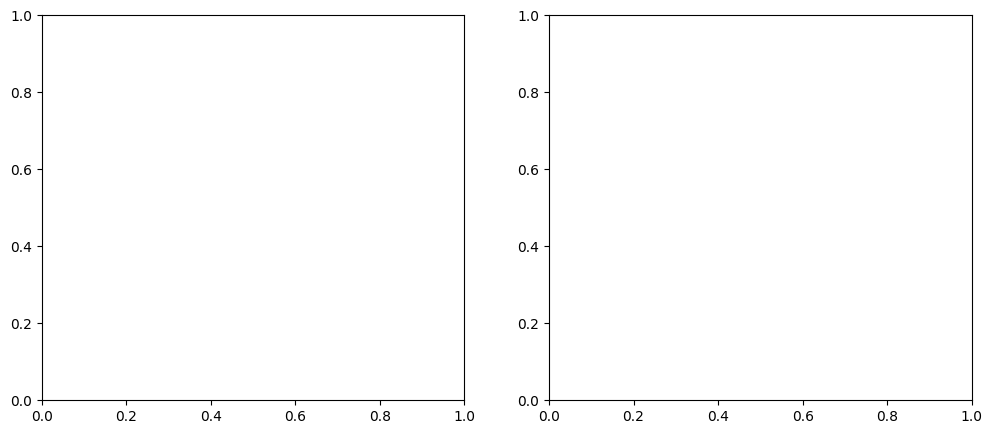

In [11]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

losses = []

xx, yy = np.meshgrid(
    np.linspace(-6,6,300),
    np.linspace(-6,6,300)
)
grid = np.c_[xx.ravel(), yy.ravel()]

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

def animate(epoch):
    ax1.clear()
    ax2.clear()

    loss = train_step(X, Y)
    losses.append(loss)

    # ---- Decision Boundary ----
    A1 = relu(grid @ W1 + b1)
    A2 = relu(A1 @ W2 + b2)
    A3 = relu(A2 @ W3 + b3)
    Z4 = softmax(A3 @ W4 + b4)
    preds = np.argmax(Z4, axis=1)

    ax1.contourf(xx, yy, preds.reshape(xx.shape),
                 cmap="coolwarm", alpha=0.4)

    ax1.scatter(X[:,0], X[:,1], c=y, s=15, cmap="coolwarm")
    ax1.set_xlim(-6,6)
    ax1.set_ylim(-6,6)
    ax1.set_title(f"Epoch {epoch}")

    # ---- Loss ----
    ax2.plot(losses, color="black")
    ax2.set_title("Cross Entropy Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")

ani = FuncAnimation(fig, animate, frames=200, interval=80)
plt.show()